In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from essential_functions import scatter_comparison_train_test_plot
from hc_clustering import HCFeatureEngineer
import warnings
warnings.filterwarnings('ignore')

/Users/danmayonde/Desktop/ML_Master_Project/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# The output directory of all the files saved in this notebook
output_path = os.path.join('..', 'feature_importance')

In [3]:
# Load Data

df = ((pd.read_csv("../Data/BData.csv")).drop(columns=["Sample_ID"])).dropna()

# Transform Aspect to Sine and Cosine
aspect_rad = np.radians(df["Aspect (˚)"])   # Convert to radians

# Insert the two new features next to "Aspect (˚)"
df.insert(5, "aspect_sin", np.sin(aspect_rad))
df.insert(6, "aspect_cos", np.cos(aspect_rad))

# Drop "Aspect (˚)" from the data frame
df.drop(["Aspect (˚)"], axis=1, inplace=True)

# Encode the Categorical Feature "Land Use" to 1 for "residential" and 0 for "barren"
df["Land Use"] = (df["Land Use"] == "residential").astype(int)

df.head()

,Longitude,Latitude,Slope (%),Elevation (m),aspect_sin,aspect_cos,NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,1554,-0.371390,0.928477,0.0655,0,2473,1535,...,91.2,7.6,1.2,7.3,100.0,50.0,1.56,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,1557,0.800000,-0.600000,0.0684,0,2507,1533,...,87.9,10.4,1.6,7.9,137.0,68.0,1.65,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,1555,0.633238,-0.773957,0.0672,0,2529,1521,...,91.8,7.0,1.3,7.1,109.0,54.5,2.62,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,1551,0.832050,-0.554700,0.0590,0,2559,1511,...,89.7,8.8,1.5,7.5,90.0,44.5,2.25,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,1554,0.554700,-0.832050,0.0593,0,2511,1470,...,86.4,12.0,1.6,8.0,119.0,59.5,2.12,384.931,26.657,8.338


## Log Transformation

In [4]:
# Log10 Transformation
print('/.. run log transformation...')
# Variables to transform
feat_transform = ["Clay (%)", "TDS (mg/L)", "SOM (g/kg)", 'NDVI']

# log10 transformation of highly skewed input variables
for feature in feat_transform:
    df[feature] = np.log10(df[feature])

print('feature transformation complete...') 

/.. run log transformation...
feature transformation complete...


In [5]:
targets = ['Cu (mg/kg)', 'Zn (mg/kg)', 'Pb (mg/kg)']
redundant_features = ["Longitude", "Latitude", "Dist_Main_Road  (m)", "EC (µs/cm)", "Sand (%)"]

features_to_drop = targets + redundant_features

# Create X Data and y

X = df.drop(columns=features_to_drop).copy()

y = df[targets]

feature_cols = X.columns

y.head()

,Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,247.980,30.210,9.123
1,359.081,31.586,8.282
2,243.819,31.527,5.749
3,314.907,34.707,9.071
4,384.931,26.657,8.338


In [6]:
# scoring metrics to be used for cross validation
scoring = {'r2': 'r2',
          'mae': 'neg_mean_absolute_error',
          'rmse': 'neg_root_mean_squared_error'
          }

## Split the Dataset into X_train, X_test, y_train, y_test

In [7]:
# Split the DataSet into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sperating targets array into different arrays
y_train_Cu = y_train[targets[0]]
y_train_Zn = y_train[targets[1]]
y_train_Pb = y_train[targets[2]]

y_test_Cu = y_test[targets[0]]
y_test_Zn = y_test[targets[1]]
y_test_Pb = y_test[targets[2]]


In [8]:
# HC-XGBoost Model Pipeline for Cu (mg/kg)
pipeline_Cu = Pipeline([
    ('hc_features', HCFeatureEngineer(n_clusters=2, return_scaled=False)),
    ('model', TransformedTargetRegressor(
        regressor=XGBRegressor(
            gamma=0.036,
            learning_rate=0.3,
            max_depth=5,
            n_estimators=35,
            subsample=0.1,
            random_state=42,
            device='gpu'
        ),
        func=np.log10,
        inverse_func=lambda x: 10**x
    ))
])

# Fit and predict
pipeline_Cu.fit(X_train, y_train_Cu)


# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        pipeline_Cu, X_train, y_train_Cu, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Cu = pipeline_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.1312
MAE: 53.7025
RMSE: 79.5890

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3852
MAE: 43.3487
RMSE: 74.5661


In [9]:
# Predict on the test set
y_pred_Cu = pipeline_Cu.predict(X_test)

r2 = r2_score(y_test_Cu, y_pred_Cu)
mae = mean_absolute_error(y_test_Cu, y_pred_Cu)
rmse = np.sqrt(mean_squared_error(y_test_Cu, y_pred_Cu))

# Predicting on the training set
y_train_pred_Cu = pipeline_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.2877
MAE: 48.3731
RMSE: 70.8567

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3852
MAE: 43.3487
RMSE: 74.5661


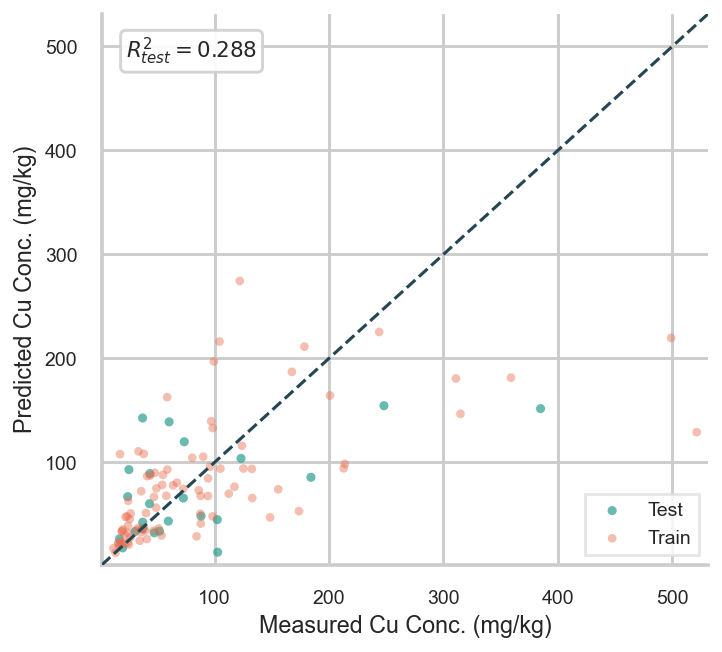

In [10]:
scatter_comparison_train_test_plot(y_pred_Cu,
                                  y_test_Cu,
                                  y_train_pred_Cu,
                                  y_train_Cu,
                                  x_label='Measured Cu Conc. (mg/kg)',
                                  y_label='Predicted Cu Conc. (mg/kg)',
                                  file_name='Cu_pred_vs_true_hc_xgboost.png')

# PREDICTION of Zn CONCENTRATIONS

In [11]:
# HC-XGBoost Model Pipeline for Zn (mg/kg)
pipeline_Zn = Pipeline([
    ('hc_features', HCFeatureEngineer(n_clusters=2, return_scaled=False)),
    ('model', TransformedTargetRegressor(
        regressor=XGBRegressor(
            gamma=0.036,
            learning_rate=0.03,
            max_depth=2,
            n_estimators=50,
            subsample=0.5,
            random_state=42,
            device='gpu'
        ),
        func=np.log10,
        inverse_func=lambda x: 10**x
    ))
])

# Fit and predict
pipeline_Zn.fit(X_train, y_train_Zn)


# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        pipeline_Zn, X_train, y_train_Zn, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Zn = pipeline_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0545
MAE: 9.7111
RMSE: 15.3441

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3103
MAE: 7.6523
RMSE: 14.6219


In [12]:
# Predict on the test set
y_pred_Zn = pipeline_Zn.predict(X_test)

r2 = r2_score(y_test_Zn, y_pred_Zn)
mae = mean_absolute_error(y_test_Zn, y_pred_Zn)
rmse = np.sqrt(mean_squared_error(y_test_Zn, y_pred_Zn))

# Predicting on the training set
y_train_pred_Zn = pipeline_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.0751
MAE: 8.0073
RMSE: 10.9311

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.3103
MAE: 7.6523
RMSE: 14.6219


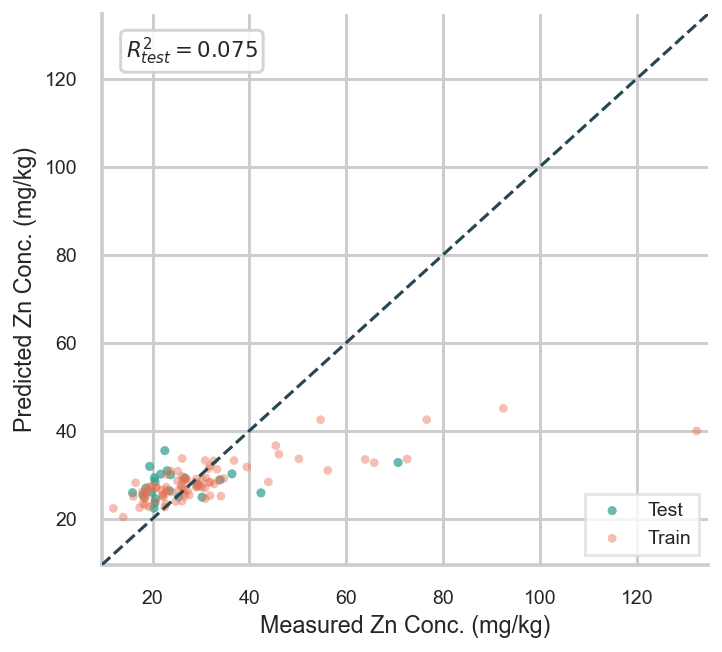

In [13]:
scatter_comparison_train_test_plot(y_pred_Zn,
                                  y_test_Zn,
                                  y_train_pred_Zn,
                                  y_train_Zn,
                                  x_label='Measured Zn Conc. (mg/kg)',
                                  y_label='Predicted Zn Conc. (mg/kg)',
                                  file_name='Zn_pred_vs_true_hc_xgb.png')

# PREDICTION OF Pb CONCENTRATIONS

In [14]:
# HC-XGBoost Model Pipeline for Pb (mg/kg)
pipeline_Pb = Pipeline([
    ('hc_features', HCFeatureEngineer(n_clusters=2, return_scaled=False)),
    ('model', TransformedTargetRegressor(
        regressor=XGBRegressor(
            gamma=0.129,
            learning_rate=0.2,
            max_depth=2,
            n_estimators=25,
            subsample=0.5,
            random_state=42,
            device='gpu'
        ),
        func=np.log10,
        inverse_func=lambda x: 10**x
    ))
])

# Fit and predict
pipeline_Pb.fit(X_train, y_train_Pb)


# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        pipeline_Pb, X_train, y_train_Pb, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Pb = pipeline_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0523
MAE: 4.5240
RMSE: 8.2999

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4912
MAE: 3.1089
RMSE: 6.8031


In [15]:
# Predict on the test set
y_pred_Pb = pipeline_Pb.predict(X_test)

r2 = r2_score(y_test_Pb, y_pred_Pb)
mae = mean_absolute_error(y_test_Pb, y_pred_Pb)
rmse = np.sqrt(mean_squared_error(y_test_Pb, y_pred_Pb))

# Predicting on the training set
y_train_pred_Pb = pipeline_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.1900
MAE: 3.9632
RMSE: 9.7485

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4912
MAE: 3.1089
RMSE: 6.8031


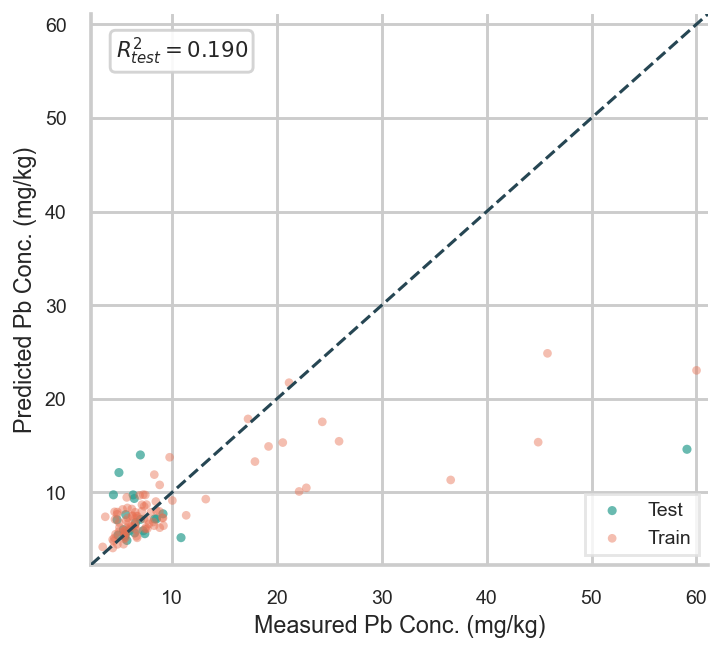

In [16]:
scatter_comparison_train_test_plot(y_pred_Pb,
                                  y_test_Pb,
                                  y_train_pred_Pb,
                                  y_train_Pb,
                                  x_label='Measured Pb Conc. (mg/kg)',
                                  y_label='Predicted Pb Conc. (mg/kg)',
                                  file_name='Pb_pred_vs_true_hc_xgb.png')